# Módulo 3 - Desafio 4
## Tabaquismo y gestación

En este documento validaremos nuestros conocimientos sobre variables aleatorias. Para ello exploraremos un dataset que contiene información básica sobre el bebe y la madre.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

df_baby = pd.read_csv('baby.csv')
df_baby.head()

,Unnamed: 0,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight,Maternal.Smoker
0,1,120,284,27,62,100,False
1,2,113,282,33,64,135,False
2,3,128,279,28,64,115,True
3,4,108,282,23,67,125,True
4,5,136,286,25,62,93,False


In [2]:
# Tenemos una columna adicional que corresponde al índice de los datos. La eliminaremos.
df_baby.drop(columns=['Unnamed: 0'], inplace=True)

### Pregunta 1
Realiza una exploración de los datos, considerando sus tipos y los descriptivos correspondientes.

In [3]:
df_baby.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Birth.Weight               1174 non-null   int64
 1   Gestational.Days           1174 non-null   int64
 2   Maternal.Age               1174 non-null   int64
 3   Maternal.Height            1174 non-null   int64
 4   Maternal.Pregnancy.Weight  1174 non-null   int64
 5   Maternal.Smoker            1174 non-null   bool 
dtypes: bool(1), int64(5)
memory usage: 47.1 KB


Vemos que todos los datos son numéricos, excepto Maternal.Smoker que corresponde a un boolean. Puede interpretarse como una variable categórica (es o no fumadora).

In [4]:
df_baby.isna().sum()

Birth.Weight                 0
Gestational.Days             0
Maternal.Age                 0
Maternal.Height              0
Maternal.Pregnancy.Weight    0
Maternal.Smoker              0
dtype: int64

Datos limpios sin nulos.

In [5]:
df_baby.describe().T

,count,mean,std,min,25%,50%,75%,max
Birth.Weight,1174.0,119.462521,18.328671,55.0,108.00,120.0,131.0,176.0
Gestational.Days,1174.0,279.101363,16.010305,148.0,272.00,280.0,288.0,353.0
Maternal.Age,1174.0,27.228279,5.817839,15.0,23.00,26.0,31.0,45.0
Maternal.Height,1174.0,64.049404,2.526102,53.0,62.00,64.0,66.0,72.0
Maternal.Pregnancy.Weight,1174.0,128.478705,20.734282,87.0,114.25,125.0,139.0,250.0


<Axes: >

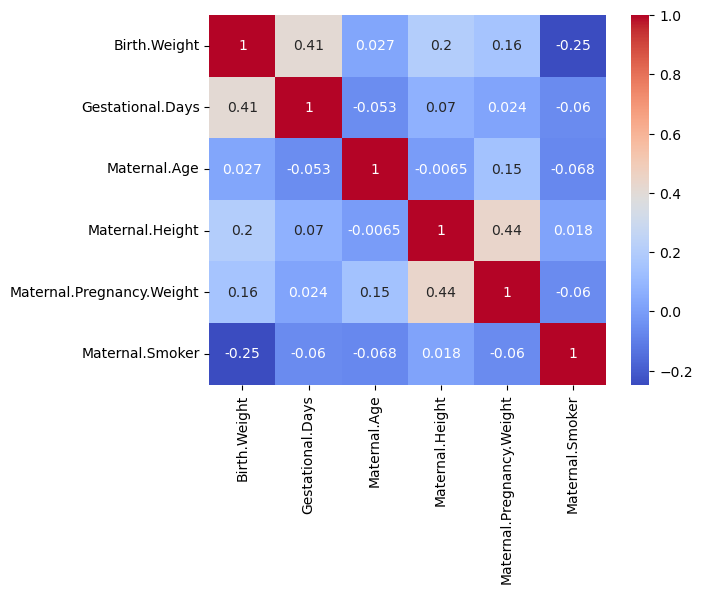

In [6]:
sns.heatmap(df_baby.corr(), annot=True, cmap='coolwarm')

A simple vista, los datos no se ven muy correlacionados entre si. Revisemos ahora la distribución general de cada columna.

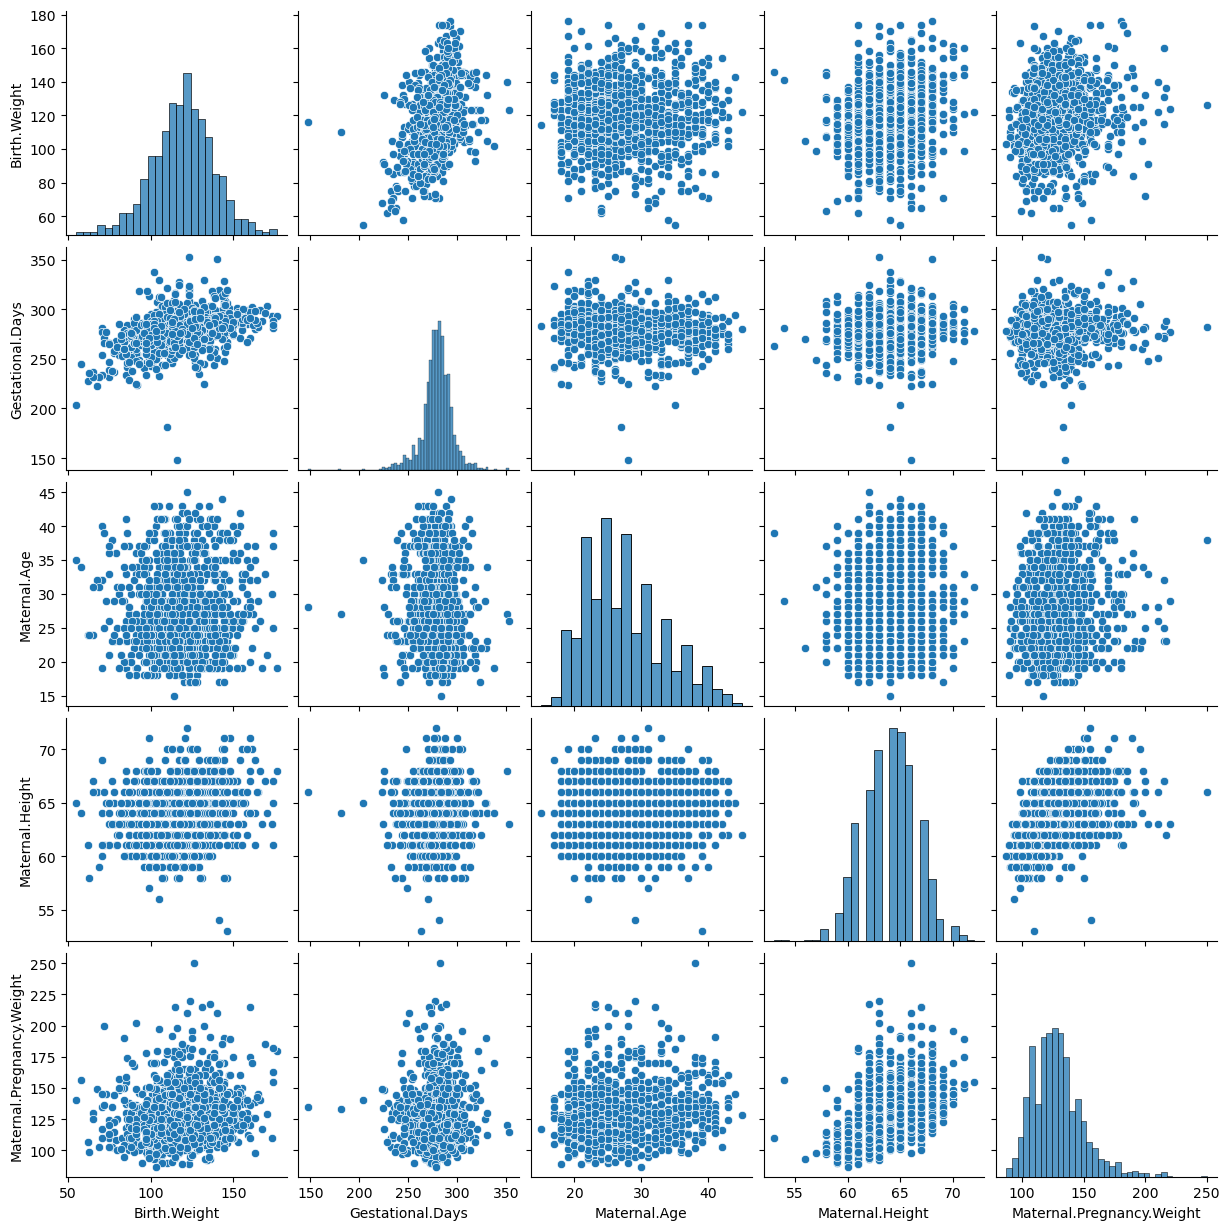

In [7]:
# Quitamos la columna categórica para graficar las relaciones entre las variables numéricas
sns.pairplot(df_baby.drop(columns=['Maternal.Smoker']))

Podemos apreciar que los datos no se correlacionan entre si, y que algunas de estas columnas parecieran tener una distribución normal.

### Pregunta 2
Considera los pesos de los bebés. ¿Se puede decir que siguen una distribución normal? Justifica tu respuesta creando los gráficos y modelos necesarios.
____

Primero graficaremos los datos para visualizar si siguen una distribución normal.

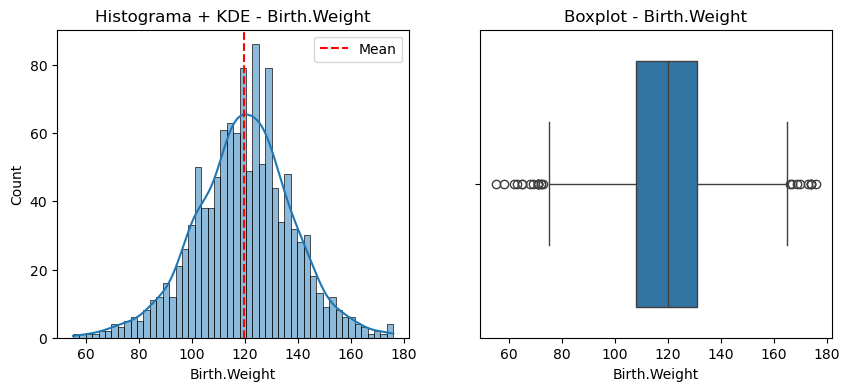

In [8]:
# Graficamos el histograma con KDE y el boxplot para Birth.Weight
df_baby_weight = df_baby['Birth.Weight'] 
mean = np.mean(df_baby_weight)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df_baby_weight, bins=50, kde=True)
plt.axvline(mean, color='r', linestyle='--', label='Mean')
plt.title('Histograma + KDE - Birth.Weight')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(x=df_baby_weight)
plt.title('Boxplot - Birth.Weight')
plt.show()

Podemos visualizar que el peso de un recién nacido sigue una distribución normal, y la presencia de varios outliers. Ahora verificaremos la hipótesis de si sigue una distribución normal generando nuestro modelo.

Primero definiremos una función que utilzaremos recurrentemente para generar la distribución normal, utilizando el promedio, la desviación estándar, y el máximo y el mínimo para generar datos equidistantes.

In [9]:
def generate_dist(serie):
    mean = np.mean(serie)
    std_dev = np.std(serie)
    min_val = np.min(serie)
    max_val = np.max(serie)
    x = np.linspace(min_val, max_val)
    pdf = stats.norm.pdf(x, loc=mean, scale=std_dev)
    return x, pdf, mean, std_dev

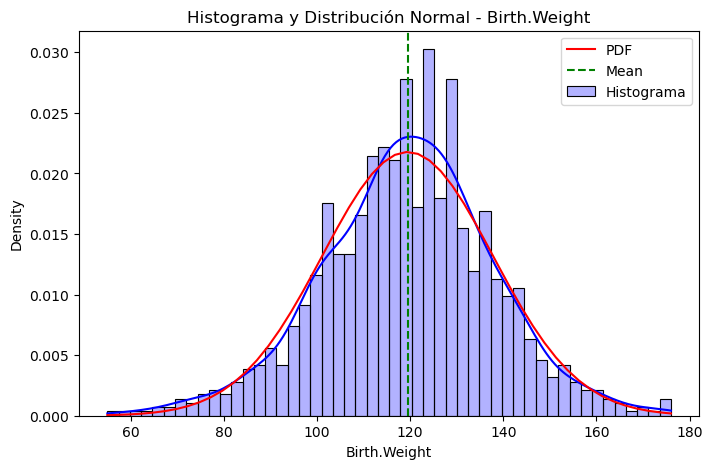

In [10]:
# Generamos nuestros datos utilizando la función
weight, pdf, mean, std_dev = generate_dist(df_baby_weight)

# Graficamos el histograma y la distribución normal
plt.figure(figsize=(8, 5))
sns.histplot(df_baby_weight, bins=50, kde=True, stat='density', color='blue', alpha=0.3, label='Histograma')
plt.plot(weight, pdf, 'r-', label='PDF')
plt.axvline(mean, color='g', linestyle='--', label='Mean')
plt.title('Histograma y Distribución Normal - Birth.Weight')
plt.xlabel('Birth.Weight')
plt.legend()
plt.show()

Vemos que la mayor parte de los datos se ajustan a la distribución generada, y que la curva KDE de los datos se asemeja en gran medida a la distribución normal generada. También vemos que hay mayor concentración de datos cerca de la media, es decir, que su densidad se escapa por encima de la distribución.

### Pregunta 3
Considerando lo anterior, verifica el model de distribución normal de los pesos para 5 valores diferentes. Compara con los datos reales.
___

Definiremos 5 valores de pesos de bebes, y veremos donde caen dentro de los datos comparando con la distribución normal generada. 

In [11]:
pesos = [90, 110, 120, 130, 150]

for peso in pesos:
    peso_teorico = stats.norm.cdf(peso, loc=mean, scale=std_dev)*100
    peso_real = stats.percentileofscore(df_baby_weight, peso)
    print(f'Peso: {peso} - Densidad Teórica: {peso_teorico} - Percentil Real: {peso_real}')

Peso: 90 - Densidad Teórica: 5.390221513115038 - Percentil Real: 5.664395229982964
Peso: 110 - Densidad Teórica: 30.275652232430904 - Percentil Real: 28.066439522998294
Peso: 120 - Densidad Teórica: 51.170208077139534 - Percentil Real: 50.383304940374785
Peso: 130 - Densidad Teórica: 71.74093902161573 - Percentil Real: 73.29642248722317
Peso: 150 - Densidad Teórica: 95.22243380229664 - Percentil Real: 95.61328790459966


Podemos apreciar que en general lo teórico y lo real se asemejan. Más cerca del centro (peso 110, 120 y 130) difieren un poco estos valores, pero siguen estando relativamente cerca unos de otros.

### Pregunta 4
Compara los pesos de los bebés de madres fumadoras y no fumadoras. ¿Qué
diferencias existen? Explica y construye los modelos correspondientes.
___
Primero visualizemos la información que tenemos sobre las madres que fuman y las que no con respecto al peso de los bebes.

<Axes: xlabel='Birth.Weight', ylabel='Count'>

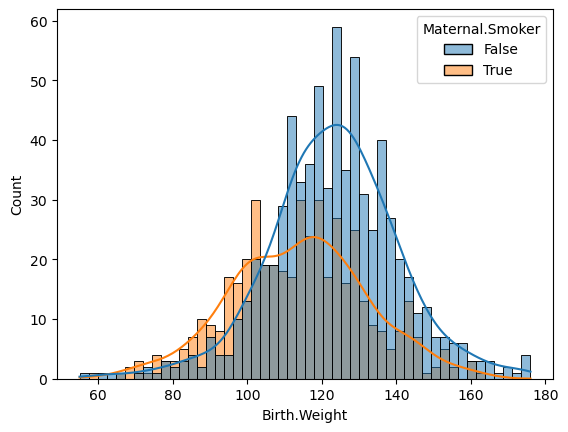

In [12]:
sns.histplot(df_baby, x='Birth.Weight', bins=50, kde=True, hue='Maternal.Smoker')

Vemos que para las no fumadoras los pesos de los bebes siguen una distribución similar a una normal, mientras que para las fumadoras los pesos colapsan alrededor de donde estaría la campana. También que la curva para las madres fumadoras se encuentra desplazada hacia la izquierda, sugiriendo que los bebes de madres fumadoras pesan menos.

Ahora calcularemos las distribuciones normales de ambas condiciones, y visualizaremos las diferencias.

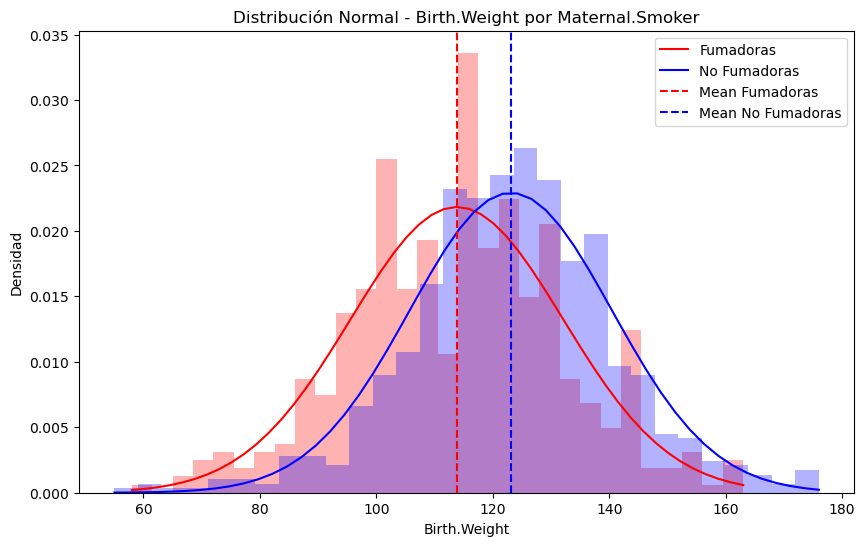

In [13]:
pesos_bebes_madres_fumadoras = df_baby[df_baby['Maternal.Smoker'] == True]['Birth.Weight']
pesos_bebes_madres_no_fumadoras = df_baby[df_baby['Maternal.Smoker'] == False]['Birth.Weight']

x_smoker, pdf_smoker, mean_smoker, std_dev_smoker = generate_dist(pesos_bebes_madres_fumadoras)
x_non_smoker, pdf_non_smoker, mean_non_smoker, std_dev_non_smoker = generate_dist(pesos_bebes_madres_no_fumadoras)

plt.figure(figsize=(10, 6))
plt.plot(x_smoker, pdf_smoker, 'r-', label='Fumadoras')
plt.hist(pesos_bebes_madres_fumadoras, bins=30, density=True, alpha=0.3, color='r')
plt.plot(x_non_smoker, pdf_non_smoker, 'b-', label='No Fumadoras')
plt.hist(pesos_bebes_madres_no_fumadoras, bins=30, density=True, alpha=0.3, color='b')
plt.axvline(mean_smoker, color='r', linestyle='--', label='Mean Fumadoras')
plt.axvline(mean_non_smoker, color='b', linestyle='--', label='Mean No Fumadoras')
plt.title('Distribución Normal - Birth.Weight por Maternal.Smoker')
plt.xlabel('Birth.Weight')
plt.ylabel('Densidad')
plt.legend()
plt.show()


En efecto, podemos ver que tanto la distribución como el promedio de los pesos de los bebes de madres fumadores se encuentran desplazados hacia la izquierda respecto de las madres no fumadoras.

### Pregunta 5
Considerando los datos dados:
- Calcula la probabilidad de que una madre escogida al azar fume
- A partir del valor anterior, construye un modelo de distribución binomial que modele el experimento correspondiente a escoger 5 madres al azar y observar cuántas fuman.
- Utilizando este modelo, simula 1000 muestras de tamaño 9, y calcula sus medias muestrales.
- Utilizando los datos directamente, extrae 1000 muestras de tamaño 8 y calcula sus respectivas medias muestrales.

Utilizando lo anterior:
- Compara gráficamente los resultados obtenidos anteriormente
- Verifica el teorema del límite central, considerando las muestras de datos reales y las simuladas con el modelo binomial.
- Construye un modelo de distribución normal derivado del modelo binomial, y grafícalo junto a los anteriores para comparar. Concluye.
___

In [14]:
# Calculamos la probabilidad de que una madre escogida al azar fume
# Sumamos la columna booleana (True=1, False=0) y dividimos por el total de filas
prob_fumar = df_baby['Maternal.Smoker'].sum()/df_baby.shape[0]
print(f'Probabilidad de que una madre fume: {prob_fumar*100:.2f}%')

Probabilidad de que una madre fume: 39.10%


In [15]:
n = 5  # número de ensayos
k_values = np.arange(0, n+1)  # posibles éxitos de 0 a n
dist_bin = stats.binom.pmf(k_values, n, prob_fumar)
for k, prob in zip(k_values, dist_bin):
    print(f'P(X={k}) = {prob*100:.1f}%')

P(X=0) = 8.4%
P(X=1) = 26.9%
P(X=2) = 34.5%
P(X=3) = 22.2%
P(X=4) = 7.1%
P(X=5) = 0.9%


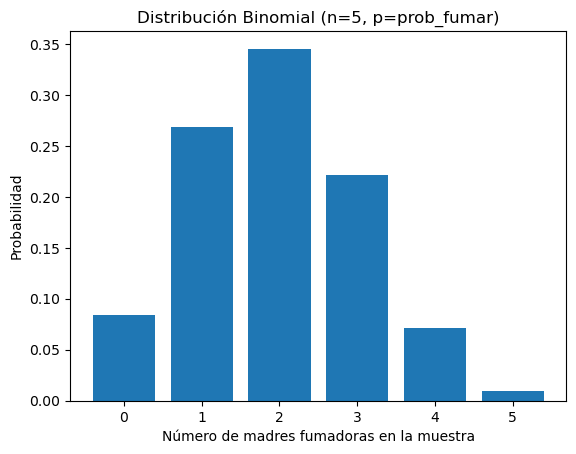

In [16]:
# Representación gráfica de la distribución binomial
plt.bar(k_values, dist_bin)
plt.xlabel('Número de madres fumadoras en la muestra')
plt.ylabel('Probabilidad')
plt.title('Distribución Binomial (n=5, p=prob_fumar)')
plt.show()

Esto nos dice que dada una muestra al azar de 5 mujeres hay:
- Un $8.4\%$ de que ninguna fume
- Un $26.9\%$ de que al menos una fume
- Un $34.5\%$ de que al menos dos fumen
- Un $22.2\%$ de que al menos tres fumen
- Un $7.1\%$ de que al menos cuatro fumen
- Un $0.9\%$ de que todas fumen

Ahora simularemos y extraeremos 1000 muestras utilizando el modelo binomial y los datos, para calcular medias muestrales.

In [17]:
# Valores comunes
tamaño = 8
n = 5
num_simulations = 1000

# Simulación de 1000 muestras de tamaño 8
medias_simuladas = []
for _ in range(num_simulations):
    muestra = np.random.binomial(n=n, p=prob_fumar, size=tamaño)
    medias_simuladas.append(np.mean(muestra))

medias_simuladas[0:10]

[np.float64(2.25),
 np.float64(2.0),
 np.float64(1.625),
 np.float64(2.375),
 np.float64(1.5),
 np.float64(1.5),
 np.float64(1.875),
 np.float64(1.375),
 np.float64(1.875),
 np.float64(2.125)]

In [18]:
medias_reales = []
madres_fumadoras = df_baby['Maternal.Smoker']
fuma = np.where(madres_fumadoras, 1, 0)

for k in range(1000):
    muestra = []
    for m in range(8):
        muestra.append(sum(np.random.choice(fuma, size=5, replace=False)))
    medias_reales.append(np.mean(muestra))

medias_reales[0:10]

[np.float64(2.0),
 np.float64(1.375),
 np.float64(2.0),
 np.float64(1.75),
 np.float64(1.875),
 np.float64(2.125),
 np.float64(1.5),
 np.float64(1.375),
 np.float64(1.625),
 np.float64(1.875)]

Construidos los modelos, procederemos a la comparación gráfica de estos, verificaremos el teorema del límite central considerando ambas muestras, y por último construiremos el modelo de distribución normal derivado del modelo binomial para compararlo con los ya construidos.

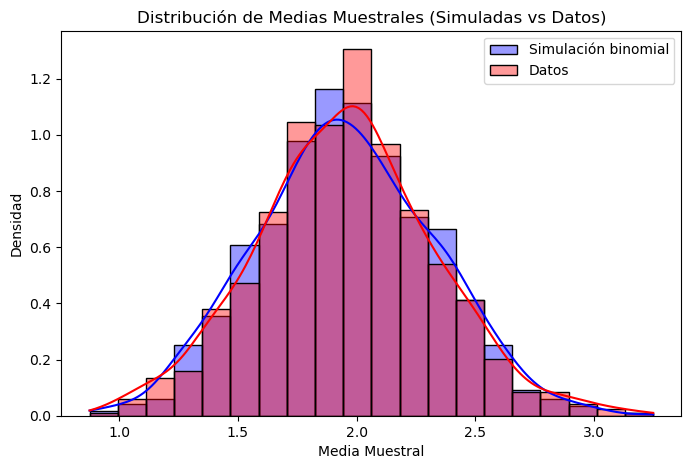

In [19]:
# Graficamos la distribución de las medias muestrales simuladas y de los datos
plt.figure(figsize=(8, 5))
sns.histplot(medias_simuladas, bins=20, kde=True, color='blue', label='Simulación binomial', alpha=0.4, stat='density')
sns.histplot(medias_reales, bins=20, kde=True, color='red', label='Datos', alpha=0.4, stat='density')
plt.title('Distribución de Medias Muestrales (Simuladas vs Datos)')
plt.xlabel('Media Muestral')
plt.ylabel('Densidad')
plt.legend()
plt.show()

Podemos ver cómo se distribuyen las medias muestrales bajo el modelo binomial. Esta simulación permite comparar la variabilidad teórica con la observada en los datos reales, y vemos que ambas distribuciones muestrales tienen la forma de una distribución normal, por lo que se verifica el teorema del límite central.

In [20]:
media_binomial = n * prob_fumar
media_binomial

np.float64(1.954855195911414)

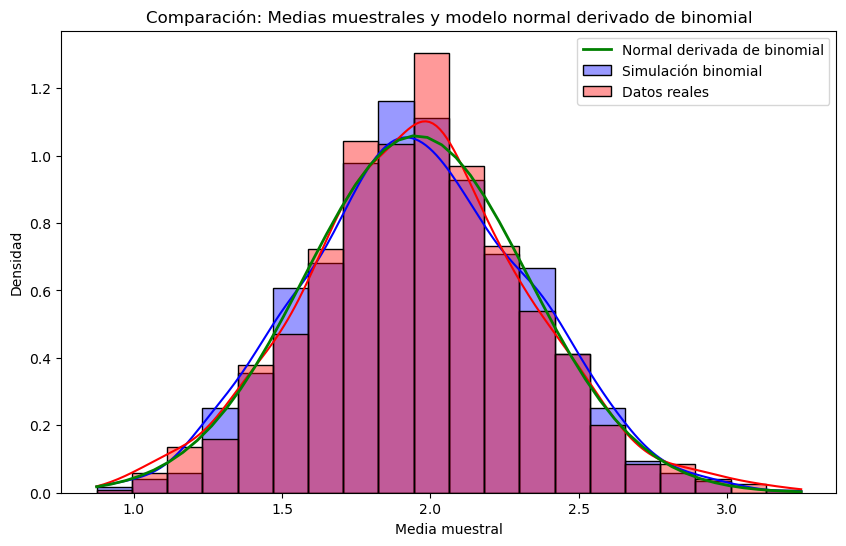

In [21]:
# La distribución binomial puede aproximarse a una normal si n es suficientemente grande.
# Calculamos la media y desviación estándar teórica de la binomial:
media_binomial = np.mean(medias_simuladas)
std_binomial = np.std(medias_simuladas)
min_binomial = np.min(medias_simuladas)
max_binomial = np.max(medias_simuladas)

# Generamos la curva de la normal teórica derivada de la binomial
x_norm = np.linspace(min_binomial, max_binomial)
pdf_norm = stats.norm.pdf(x_norm, loc=media_binomial, scale=std_binomial)

plt.figure(figsize=(10,6))
sns.histplot(medias_simuladas, bins=20, kde=True, color='blue', label='Simulación binomial', alpha=0.4, stat='density')
sns.histplot(medias_reales, bins=20, kde=True, color='red', label='Datos reales', alpha=0.4, stat='density')
plt.plot(x_norm, pdf_norm, 'g-', label='Normal derivada de binomial', linewidth=2)
plt.title('Comparación: Medias muestrales y modelo normal derivado de binomial')
plt.xlabel('Media muestral')
plt.ylabel('Densidad')
plt.legend()
plt.show()

Vemos que las 3 curvas siguen una distribución normal. La distribución normal generada a partir de la simulación nos indica que la simulación binomial se ajusta a la información del dataset con respecto a las distribución de madres fumadoras. Además, verificamos el teorema del límite central ya que, aunque la variable en cuestion es binomial, la distribución de las medias muestrales se comporta como una distribución normal.